In [5]:
import os
import importlib
import urllib.request
import pandas as pd
pd.set_option("display.width", 200)              # Gesamtbreite
pd.set_option("display.max_columns", None)       # alle Spalten
pd.set_option("display.max_colwidth", 120)       # max Breite pro Zelle (None = unendlich)
pd.set_option("display.expand_frame_repr", False) # keine Zeilenumbrüche in DataFrame-Ansicht

import polytope as pc
importlib.reload(pc)

import matplotlib.pyplot as plt

Download the [list of all 4319](http://hep.itp.tuwien.ac.at/%7Ekreuzer/pub/K3/RefPoly.d3) reflexive 3D polytopes from M. Kreuzer, H. Skarke (TU Wien), see [landing page](http://hep.itp.tuwien.ac.at/~kreuzer/CY/CYk3.html).

In [6]:
file_path = r"C:\Users\esultano\git\polytopes\data\tuwien\RefPoly.d3"
file_url = "http://hep.itp.tuwien.ac.at/~kreuzer/pub/K3/RefPoly.d3"

if not os.path.exists(file_path):
    print("File not found. Downloading now...")
    # Create directories if they don't exist
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    
    # Download the file
    urllib.request.urlretrieve(file_url, file_path)
    print("Download completed.")
else:
    print("File already exists at the specified location.")

File already exists at the specified location.


In [7]:
data = {
    "dimension": [],
    "num_vertices": [],
    "m_lattice_points": [],
    "m_vertices": [],
    "n_lattice_points": [],
    "n_vertices": [],
    "picard_number": [],
    "correction": [],
    "inequalities": []   # korrekt benannt!
}


with open(file_path, "r") as file:
    while True:
        line = file.readline()
        if not line:
            break

        line = line.strip()
        if not line:
            continue

        if line.startswith("3 "):
            parts = line.split()

            dimension = int(parts[0])
            num_vertices = int(parts[1])
            m_lattice_points = int(parts[2][2:])
            m_vertices = int(parts[3])
            n_lattice_points = int(parts[4][2:])
            n_vertices = int(parts[5])
            picard_number = int(parts[6][4:])
            correction = int(parts[7][4:])

            data["dimension"].append(dimension)
            data["num_vertices"].append(num_vertices)
            data["m_lattice_points"].append(m_lattice_points)
            data["m_vertices"].append(m_vertices)
            data["n_lattice_points"].append(n_lattice_points)
            data["n_vertices"].append(n_vertices)
            data["picard_number"].append(picard_number)
            data["correction"].append(correction)

            # ✅ EXACTLY dimension (=3) lines follow
            rows = []
            for _ in range(dimension):
                row = list(map(int, file.readline().split()))
                if len(row) != num_vertices:
                    raise ValueError(f"Expected {num_vertices} entries, got {len(row)}")
                rows.append(row)

            data["inequalities"].append(rows)

df_poly3d = pd.DataFrame(data)
#print(df_poly3d.head())

vertex_counts_3d_df = (df_poly3d["num_vertices"].value_counts().sort_index().rename_axis("vertex_count").reset_index(name="count"))
print(vertex_counts_3d_df)

    vertex_count  count
0              4     48
1              5    250
2              6    611
3              7    964
4              8   1051
5              9    801
6             10    405
7             11    143
8             12     37
9             13      8
10            14      1


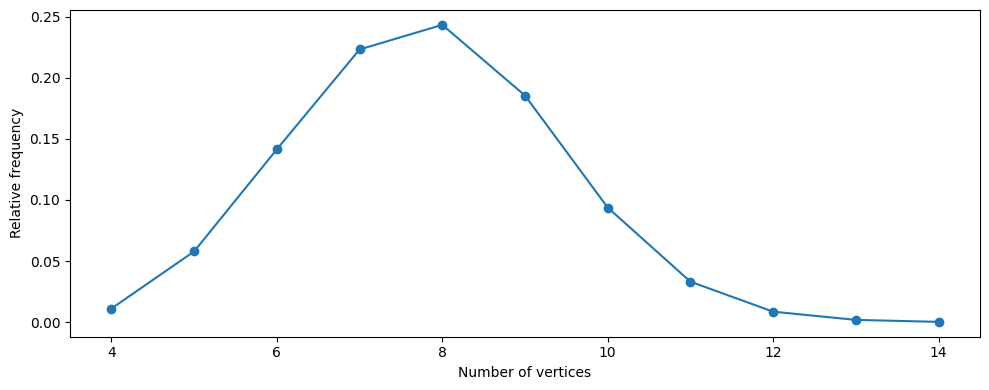

In [9]:
vertex_count_distribution_3d = df_poly3d['num_vertices'].value_counts().sort_index()

# Normalize the distributions
vertex_count_distribution_3d_norm = vertex_count_distribution_3d / vertex_count_distribution_3d.sum()

plt.figure(figsize=(10, 4))

plt.plot(
    vertex_count_distribution_3d_norm.index,
    vertex_count_distribution_3d_norm.values,
    marker="o",
    linestyle="-"
)

plt.xlabel("Number of vertices")
plt.ylabel("Relative frequency")

plt.tight_layout()
plt.savefig("../../plot/poly3d-normalized-vertex-dist.png", dpi=300, bbox_inches="tight")
plt.show()